In [249]:
import numpy as np
import math
import scipy.stats as stat
import matplotlib.pyplot as plt

### 2.

In [20]:
S0 = 100; sigma = 0.2; r=0.02; delta=0.01; T=0.5; K=100
N=100; u = np.exp(sigma*np.sqrt(T/N)); d=1/u
qu = (np.exp((r-delta)*(T/N))-d)/(u-d)
qd = 1-qu

In [146]:
print(qu)

0.498232277240668


#### a

In [21]:
eur_put = lambda s,K : np.maximum(K-s,0)
def binom_eur(u,d,qu,r,T,S0,K,N,payoff):

    v = 0
    for k in range(N+1):
        v+= (stat.binom.pmf(k,N,qu)*payoff(S0 * u**k * d**(N-k),K))

    return np.exp(-(r)*T)*v

v = binom_eur(u,d,qu,r,T,S0,K,N,eur_put)
print(v)

5.336474235693077


#### b

In [ ]:
def binom_am(u,d,qu,r,T,S0,K,N,payoff):
    S = np.zeros(shape=(N+1,N+1))
    S[:,0] = S0
    for j in range(N+1):
        for i in range(j):
            S[i,j] = S[i,j-1] * u**i *d**(j-i)
    pass

In [237]:
N = 100
S = np.zeros(shape=(N+1,N+1))
S[:,0] = S0
for i in range(N+1):
    for j in range(N+1):
       S[i,j] = S0 * u**i * d**(j-i)


In [238]:
print(S)

[[ 100.           98.59573946   97.2111984  ...   25.00912842
    24.6579351    24.31167344]
 [ 102.86880693  101.42426087  100.         ...   25.72659203
    25.36532365   25.00912842]
 [ 105.81991439  104.33392709  102.86880693 ...   26.46463828
    26.09300581   25.72659203]
 ...
 [1598.8322024  1576.38043273 1554.24394441 ...  399.85399865
   394.23900675  388.70286396]
 [1644.69961142 1621.60374383 1598.8322024  ...  411.32503788
   405.54896269  399.85399865]
 [1691.88286786 1668.12442442 1644.69961142 ...  423.12515907
   417.18337944  411.32503788]]


In [239]:
h = []
for i in range(N+1): 
    h.append(eur_put(S[:(N-i+1),N-i],K)[::-1])
print(h)

[array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  2.7888016 ,  5.49982905,  8.13525133, 10.6971769 ,
       13.18765546, 15.60867951, 17.962186  , 20.25005787, 22.47412553,
       24.63616836, 26.7379161 , 28.78105026, 30.76720547, 32.69797075,
       34.57489081, 36.3994673 , 38.17315998, 39.89738788, 41.5

In [240]:
h1 = []
for i in range(1,N): 
    h2 = []
    for j in range(N-i+1):
        # print(qu*h[i][j]+qd*h[i][j-1])
        h2.append(h[i][j])
    h1.append(h2)


In [247]:
m1 = []
node = []
for i in range(N): 
    m2 = []
    if i == 0:
        for j in range(N-i):
            # print(qu*h[i][j]+qd*h[i][j-1])
            # print(h1[i][j])
            m2.append(np.maximum(np.exp(-r*(T/N))*(qu*h[i][j] + qd*(h[i][j+1])),h1[i][j]))
        m1.append(m2)
    elif i > 0 and i < N-1:
        for j in range(N-i):
            # print(h1[i][j])
            # print(qu*h[i][j]+qd*h[i][j-1])
            m2.append(np.maximum(np.exp(-r*(T/N))*(qu*m1[i-1][j] + qd*(m1[i-1][j+1])),h1[i][j]))
        m1.append(m2)
    # if i < N-1:
    #     node.append(np.maximum(m2,h1[i]))
    # m1.append(m2)
print(np.maximum(np.exp(-r*(T/N))*(qu*m1[-1][0]+qd*m1[-1][1]),eur_put(S0,K)))
# print(node)

5.379817040498354


### 2.

In [300]:
class Brownian:
    def __init__(self,N,T,seed):
        self.seed = seed
        self.N = N
        self.T = T
        self.z1 = np.random.normal(loc=0,scale=1,size=N-1)
        self.z2 = np.random.normal(loc=0,scale=1,size=N-1)

    def genB(self):
        W = np.zeros(shape=(self.N))
        for i in range(1,self.N):
            W[i] = W[i-1]+np.sqrt(self.T/self.N)*self.z1[i-1]
        return W
    def genRhoB(self,rho):
        W = np.zeros(shape=(self.N))
        for i in range(1,self.N):
            W[i] = W[i-1]+np.sqrt(self.T/self.N)*(rho*self.z1[i-1]+np.sqrt(1-rho**2)*self.z2[i-1])
        return W


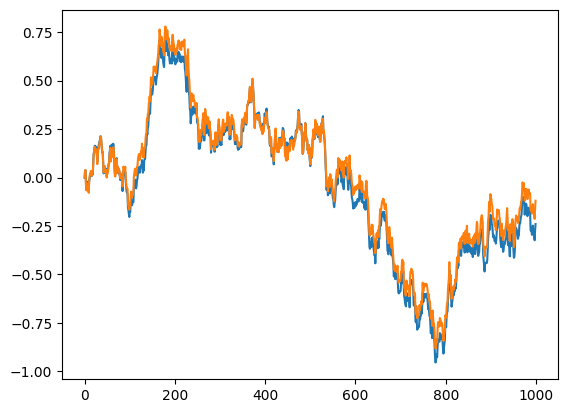

In [310]:
B = Brownian(T=1,N=1000,seed=0)
plt.plot(B.genB())
plt.plot(B.genRhoB(rho=0.99))
plt.show()

### 3.

In [325]:
B_terminal = []
for i in range(5000):
    B = Brownian(T=10,N=1000,seed=i)
    B_terminal.append(B.genB()[-1])


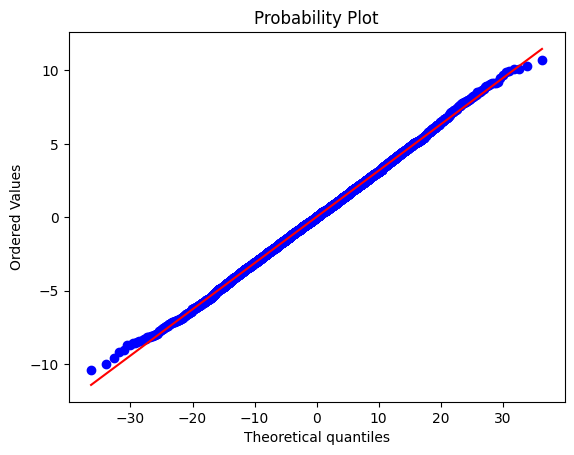

0.022107257368391645 9.89826591284279


In [326]:
stat.probplot(B_terminal,dist="norm",sparams=(0,10),plot=plt)
plt.show()
print(np.mean(B_terminal),np.var(B_terminal,ddof=1))
